In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import plotly.express as px
from gensim.models import word2vec
from gensim.corpora import Dictionary
from sklearn.manifold import TSNE as tsne

In [2]:
CORPUS = pd.read_csv("CORPUS.csv", sep="|")

# VOCAB_W2V (4)

In [3]:
#Remove missing/non-string tokens
CORPUS = CORPUS.dropna(subset=["term_str"]).copy()
CORPUS["term_str"] = CORPUS["term_str"].astype(str)

# Convert CORPUS to Gensim-style docs (list of token lists by sentence)
BAG = ['song_id', 'sent_num']

docs = CORPUS.groupby(BAG).term_str.apply(list).tolist()

# Build Gensim dictionary
dictionary = Dictionary(docs)

# Train word2vec model
w2v_params = dict(
    window=5,
    vector_size=100,
    min_count=25,
    workers=4
)

model = word2vec.Word2Vec(docs, **w2v_params)

# Convert to dataframe — this is VOCAB_W2V
VOCAB_W2V = pd.DataFrame(model.wv.vectors, index=model.wv.index_to_key)
VOCAB_W2V.index.name = 'term_str'
VOCAB_W2V

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
term_str,,,,,,,,,,,,,,,,,,,,,
i,0.037583,0.291956,1.171375,1.616473,0.251288,0.996444,0.584794,-1.010476,0.874179,-0.069409,...,0.183043,-1.497926,0.684708,-0.374238,0.695525,0.091280,1.163723,-1.507554,1.266862,0.027975
you,-0.653314,1.348768,1.172007,0.902823,1.602122,0.553243,1.243625,-1.093791,1.673900,0.353164,...,-0.597138,0.613237,0.443528,-0.896717,1.123210,0.459613,0.662362,-1.252731,0.665104,-0.476635
the,-0.359827,0.488329,-0.148071,1.006466,0.351540,1.085508,0.405034,0.547109,0.120807,-0.587052,...,-0.760263,0.573213,0.535392,0.065802,1.177175,-0.411206,0.538630,0.475815,0.726647,-0.605916
it,-0.905769,0.186601,1.731882,-0.041221,-0.493793,0.505407,0.344760,-1.056800,1.573960,0.499936,...,-1.279755,-0.164704,0.012073,-0.865104,0.455846,0.354820,-0.840676,-0.044159,-0.119780,-1.033459
me,-0.717400,0.957787,0.113555,0.325743,0.341895,0.015560,0.543145,-0.378849,0.857281,0.937818,...,-1.670985,0.343144,0.048668,-1.469638,1.141203,0.426849,0.586415,0.581193,-0.028200,-0.369391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
loaded,-0.236869,0.086116,-0.197098,-0.169274,0.191605,-0.040501,0.068549,0.178833,-0.388718,-0.185636,...,0.187029,-0.168123,0.340306,-0.156712,0.087374,0.134597,0.085334,-0.151019,0.181624,0.136840
month,-0.078708,-0.084942,-0.073776,0.144652,0.021106,-0.066305,-0.010582,0.216822,-0.016857,-0.006191,...,0.017109,-0.016304,0.100252,0.139614,0.122069,0.239320,-0.053049,-0.320101,0.054582,0.063271
45,-0.100218,-0.075174,-0.115856,-0.015321,0.045960,-0.068275,0.178550,0.142389,0.020189,-0.036429,...,0.217635,0.217010,0.071289,-0.165918,0.390996,0.467957,0.096984,-0.180202,0.047893,0.002787


In [5]:
VOCAB_W2V.to_csv("/Users/natalieseah/Desktop/TextasData/VOCAB_W2V.csv", sep="|")

# Word2vec tSNE Plot (4)

In [4]:
PP = 40

tsne_engine = tsne(
    perplexity=PP,
    n_components=2,
    init='pca',
    max_iter=2500,
    random_state=23
)

TSNE = pd.DataFrame(
    tsne_engine.fit_transform(VOCAB_W2V),
    columns=['x', 'y'],
    index=VOCAB_W2V.index
)

px.scatter(
    TSNE.reset_index(), 'x', 'y',
    text='term_str',
    hover_name='term_str',
    height=1000,
    width=1200,
    title='Word2Vec Embeddings Visualized with tSNE'
).update_traces(
    mode='markers+text',
    textfont=dict(color='black', size=10, family='Arial'),
    textposition='top center'
)

In [7]:
from sklearn.manifold import TSNE
import pandas as pd

# Get word vectors from your model
words = list(model.wv.index_to_key)
vectors = model.wv[words]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
coords = tsne.fit_transform(vectors)

# Create dataframe
coords_df = pd.DataFrame(coords, columns=['x', 'y'], index=words)

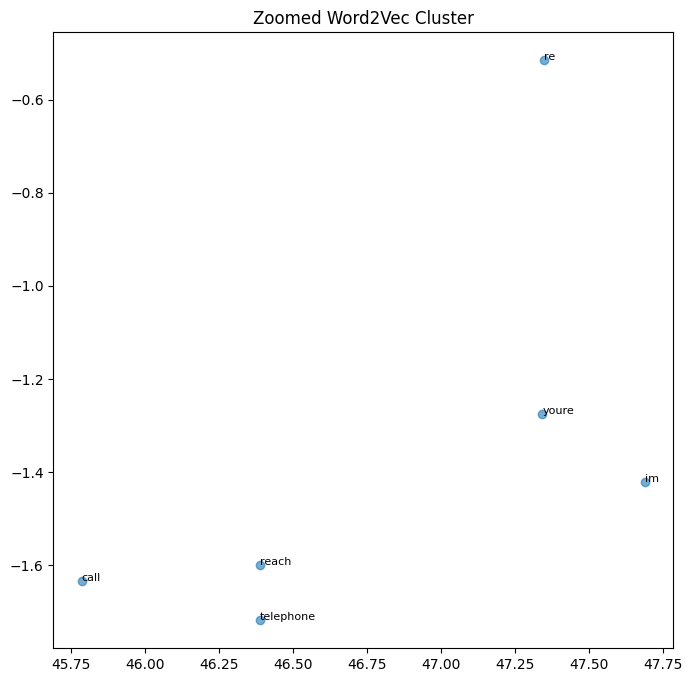

In [ ]:
import matplotlib.pyplot as plt
# Example: zoom region (adjust numbers after inspecting)
subset = coords_df[
    (coords_df['x'] > 44)  &
    (coords_df['y'] > -3) & (coords_df['y'] < 0)
]

plt.figure(figsize=(8,8))
plt.scatter(subset['x'], subset['y'], alpha=0.6)

for i, word in enumerate(subset.index):
    plt.text(subset['x'][i], subset['y'][i], word, fontsize=8)

plt.title("Zoomed Word2Vec Cluster")
plt.show()